**Import Libraries**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from xgboost import XGBClassifier

In [2]:
import zipfile
import os
zip_path = "playground-series-s6e3.zip"
extract_folder = "./extracted_data"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_folder)

print("Files:", os.listdir(extract_folder))

Files: ['sample_submission.csv', 'test.csv', 'train.csv']


**Load Dataset**

In [3]:
train = pd.read_csv("./extracted_data/train.csv")

**Preprocessing**

In [4]:
train.info()
train.head()
train.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 594194 entries, 0 to 594193
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                594194 non-null  int64  
 1   gender            594194 non-null  object 
 2   SeniorCitizen     594194 non-null  int64  
 3   Partner           594194 non-null  object 
 4   Dependents        594194 non-null  object 
 5   tenure            594194 non-null  int64  
 6   PhoneService      594194 non-null  object 
 7   MultipleLines     594194 non-null  object 
 8   InternetService   594194 non-null  object 
 9   OnlineSecurity    594194 non-null  object 
 10  OnlineBackup      594194 non-null  object 
 11  DeviceProtection  594194 non-null  object 
 12  TechSupport       594194 non-null  object 
 13  StreamingTV       594194 non-null  object 
 14  StreamingMovies   594194 non-null  object 
 15  Contract          594194 non-null  object 
 16  PaperlessBilling  59

id                  0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [5]:
x = train.drop(['Churn','id'],axis = 1)

In [6]:
y = train['Churn'].map({'No': 0, 'Yes': 1})

In [7]:
x = x.fillna(x.mode().iloc[0])

In [8]:
# Convert Yes/No to 1/0 before encoding
yes_no_cols = ['Partner','PhoneService','MultipleLines','OnlineSecurity',
               'DeviceProtection','TechSupport','StreamingTV',
               'StreamingMovies','PaperlessBilling']

for col in yes_no_cols:
    x[col] = x[col].map({'Yes':1, 'No':0})

# Create new feature
x['TotalServices'] = x[yes_no_cols].sum(axis=1)

In [9]:
x['TotalServices'] = x[yes_no_cols].sum(axis=1)
x['AvgCharges'] = x['TotalCharges'] / (x['tenure'] + 1)

**ONE HOT ENCODING**

In [10]:
x = pd.get_dummies(x, drop_first=True)

**Train Test Split**

In [11]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

**Evaluation**

In [15]:
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import StratifiedKFold, cross_val_score

# Compute scale_pos_weight
scale_pos = (y == 0).sum() / (y == 1).sum()

model = XGBClassifier(
    n_estimators=1200,
    learning_rate=0.015,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    gamma=0.2,
    reg_alpha=0.1,
    reg_lambda=1.0,
    min_child_weight=4,
    scale_pos_weight=scale_pos,
    random_state=42,
    eval_metric='auc'  # For early stopping if using fit()
)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(model, x, y, cv=cv, scoring='roc_auc')
print("CV AUC:", scores.mean())

CV AUC: 0.9162226361224672


In [17]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report

# Train model
model.fit(x_train, y_train)

# Predictions
y_pred = model.predict(x_test)

# Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")

Accuracy: 0.8209
Precision: 0.5677
Recall: 0.8759


**Visuals**

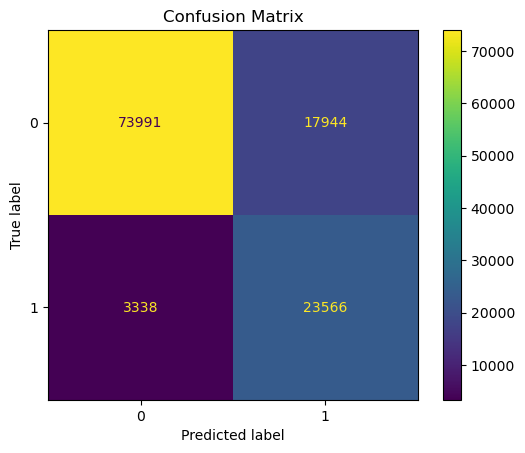

In [18]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot()
plt.title("Confusion Matrix")
plt.show()

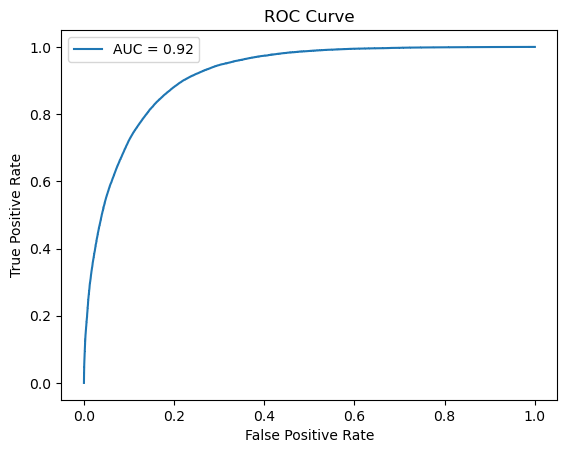

In [20]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

y_prob = model.predict_proba(x_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

**Save Model**

In [26]:
import pickle
model.fit(x_train, y_train)

# Save model
pickle.dump(model, open("model.pkl", "wb"))
pickle.dump(x.columns, open("columns.pkl", "wb"))